# Stroke Prediction — End to End Machine Learning Pipeline

## Project Overview
Stroke is one of the leading causes of death and long-term disability worldwide. Early identification of individuals at risk can help healthcare professionals take preventive measures and improve patient outcomes. In this project, a machine learning pipeline is developed to predict the likelihood of stroke using demographic, lifestyle, and medical information such as age, hypertension status, heart disease, body mass index (BMI), smoking status, and average glucose level. The goal is to build and evaluate predictive models that can assist in identifying high-risk individuals.

## Problem Statement
Stroke can occur suddenly and often results in severe health complications or death. Many of the risk factors associated with stroke can be identified before the condition occurs. However, accurately assessing an individual's risk using traditional methods can be challenging due to the complex relationships among multiple health factors. Therefore, there is a need for a data-driven approach that can analyze these factors and provide reliable predictions, enabling earlier intervention and better healthcare decision-making.

## Approach
This notebook follows a structured machine learning workflow to develop a stroke prediction model. The process includes:

Understanding and exploring the dataset through exploratory data analysis (EDA).
Cleaning and preprocessing the data by handling missing values, encoding categorical variables, and scaling numerical features where necessary.
Performing feature engineering and feature selection to improve model performance.
Addressing class imbalance in the target variable using appropriate techniques.
Training multiple machine learning models, including Logistic Regression, Random Forest, and XGBoost.
Evaluating model performance using relevant classification metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.
Selecting the best-performing model and preparing it for deployment or future use.

The final objective is to develop a robust and reliable model capable of predicting stroke risk and supporting preventive healthcare efforts.

## Dataset
The dataset used in this project is the Stroke Prediction Dataset sourced from Kaggle 
(fedesoriano, 2021). It contains 5,110 patient records with 11 clinical and demographic 
features including age, gender, hypertension, heart disease, marital status, work type, 
residence type, average glucose level, BMI, and smoking status. The target variable is 
a binary indicator of whether the patient experienced a stroke.

Source: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
from cleaning_utilitis import handle_missing, remove_duplicates, fix_dtypes, remove_outliers, clean_strings

### Exploratory Data Analysis

Before cleaning or modelling, the dataset is explored to understand its structure, 
identify missing values, examine the distribution of the target variable, and 
understand the key features.

In [3]:
# Loading dataset
df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df_raw = df.copy()

conn = sqlite3.connect("../data/raw/healthcare-dataset-stroke-data.db")
df.to_sql("stroke", conn, if_exists="replace", index=False)
print("Dataset loaded successfully into an SQLite database.")

Dataset loaded successfully into an SQLite database.


In [4]:
# First Query to check what my data looks like
pd.read_sql_query(
    """
    SELECT *
    FROM stroke
    LIMIT 5;
    """, conn
)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


The dataset contains demographic, lifestyle, and health-related information for each patient. Features include age, gender, hypertension status, heart disease status, BMI, average glucose level, smoking status, and the target variable (`stroke`).

From the first few records, we can observe that:
- Both numerical and categorical features are present.
- The target variable (`stroke`), hypertension and heart disease are encoded as 0 and 1.
- Missing values are already visible in the `bmi` column.

In [5]:
pd.read_sql_query("""
        SELECT AVG(age) AS average_age, CASE WHEN stroke = 1 THEN 'Stroke' ELSE 'No Stroke' END AS stroke_status
        FROM stroke
        GROUP BY stroke;
        """, conn)

,average_age,stroke_status
0,41.971545,No Stroke
1,67.728193,Stroke


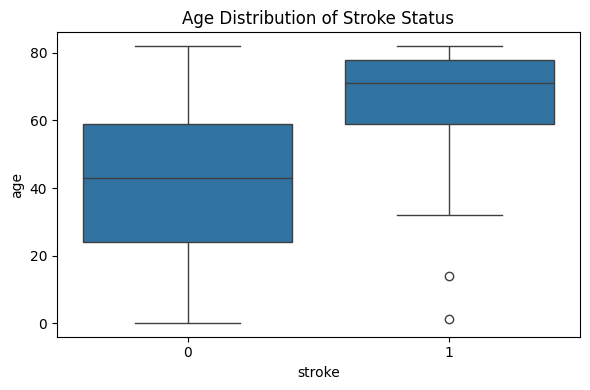

In [24]:
# visualizing the distribution of age across stroke status
plt.figure(figsize=(6, 4))
sns.boxplot(x="stroke", y="age", data=df)
plt.title("Age Distribution of Stroke Status")
plt.savefig("../outputs/figures/age_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()



The query shows that the average age of stroke patients is approximately 68 years, while non-stroke patients have an average age of about 42 years. Further visualisation showed Stroke patients are considerably older on average than non-stroke patients, suggesting age is a strong predictor of stroke risk.

In [79]:
pd.read_sql_query("""
    SELECT AVG(avg_glucose_level), CASE WHEN stroke = 1 THEN 'Stroke' ELSE 'No Stroke' END AS stroke_status
    FROM stroke
    GROUP BY stroke;
    """, conn)

,AVG(avg_glucose_level),stroke_status
0,104.795513,No Stroke
1,132.544739,Stroke


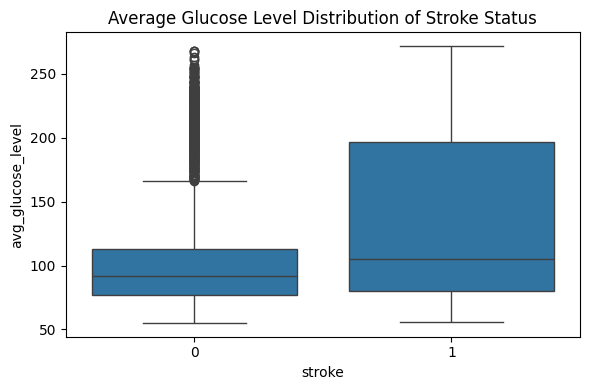

In [80]:
# visualizing the distribution of average glucose level across stroke status
plt.figure(figsize=(6, 4))
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Average Glucose Level Distribution of Stroke Status")
plt.savefig("../outputs/figures/avg_glucose_level_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

The analysis shows that patients who experienced a stroke have a substantially higher average glucose level (132.54) compared to patients who did not (104.80). This suggests a positive association between elevated glucose levels and stroke occurrence.

The boxplot further supports this observation, showing a higher median glucose level among stroke patients. In addition, the glucose distribution for the stroke group exhibits a wider spread, indicating greater variability in glucose levels among individuals who experienced a stroke.

Although some overlap exists between the two groups, stroke patients generally tend to have higher glucose levels. This suggests that average glucose level may be a useful predictor in the stroke prediction model.

In [30]:
# querying to check between gender who has the higher stroke percentage
pd.read_sql_query(
    """
    SELECT gender, 
        COUNT(*) AS total_count, 
        COUNT(CASE WHEN stroke = 1 THEN 1 END) AS stroke_count, 
        ROUND(COUNT(CASE WHEN stroke = 1 THEN 1 END) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    WHERE gender IN ('Male', 'Female')
    GROUP BY gender;
    """, conn)

,gender,total_count,stroke_count,stroke_percentage
0,Female,2994,141,4.71
1,Male,2115,108,5.11


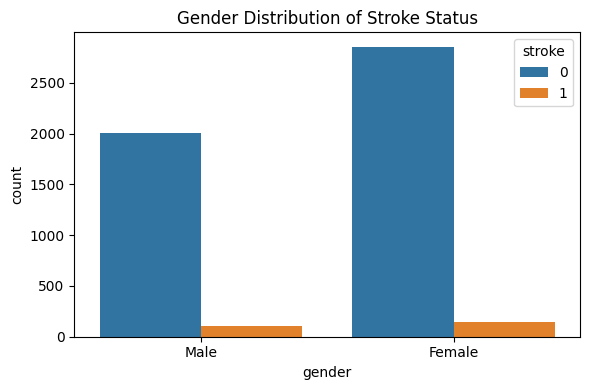

In [31]:
# visualizing 
df_clean = df[df['gender'] != 'Other']

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='gender', hue='stroke')
plt.title("Gender Distribution of Stroke Status")
plt.tight_layout()
plt.savefig("../outputs/figures/gender_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.show()

Males exhibit a slightly higher stroke percentage than females in this dataset. However, the difference is small, suggesting that gender alone may not be a strong predictor of stroke compared to factors such as age, hypertension, or heart disease.
Although the visualisation shows a higher number of stroke cases among females, this is misleading because the dataset is imbalanced in terms of total counts (females: 2,994; males: 2,115). For this reason, comparing percentages provides a more accurate understanding than raw counts.

In [32]:
# querying the data to get insights on lifestyle(smoking_status) on stroke status
pd.read_sql_query("""
    SELECT smoking_status,
    COUNT(*) AS total_counts,
    COUNT(CASE WHEN stroke = 1 THEN 1 END) AS stroke_count,
    ROUND(COUNT(CASE WHEN stroke = 1 THEN 1 END) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    GROUP BY smoking_status;
    """, conn)

,smoking_status,total_counts,stroke_count,stroke_percentage
0,Unknown,1544,47,3.04
1,formerly smoked,885,70,7.91
2,never smoked,1892,90,4.76
3,smokes,789,42,5.32


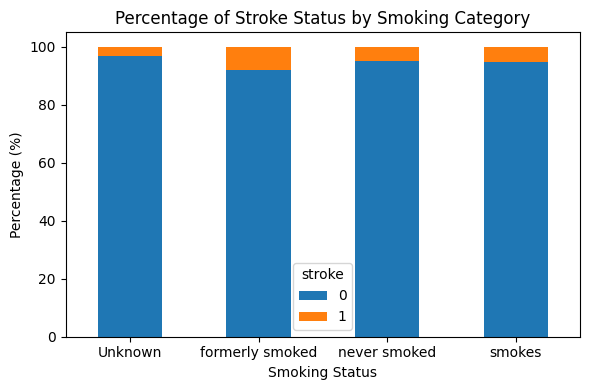

In [ ]:
# visualising
df_perc = pd.crosstab(df['smoking_status'], df['stroke'], normalize='index') * 100

df_perc.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title("Percentage of Stroke Status by Smoking Category")
plt.ylabel("Percentage (%)")
plt.xlabel("Smoking Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/smoking_status_distribution_of_smoking_status.png", dpi=150, bbox_inches='tight')
plt.show()

In [39]:
df_age = df.groupby('smoking_status')['age'].mean()
df_age

smoking_status
Unknown            30.229922
formerly smoked    54.929944
never smoked       46.744715
smokes             47.096324
Name: age, dtype: float64



The query shows that individuals who formerly smoked have the highest percentage of stroke cases, followed by those who currently smoke. This suggests a possible association between smoking history and stroke occurrence. Both current and former smokers appear to have higher stroke prevalence compared to non-smokers, indicating that smoking may be a relevant risk factor for stroke in this dataset; however, age acts as a major confounding variable here, as the "formerly smoked" group skews significantly older (average age of 55) than the other categories.

In [9]:
pd.read_sql_query("""
   SELECT
    stroke,
    AVG(bmi) AS average_bmi,
    COUNT(*) AS total_count
FROM stroke
GROUP BY stroke;
    """, conn
    )

,stroke,average_bmi,total_count
0,0,28.823064,4861
1,1,30.471292,249


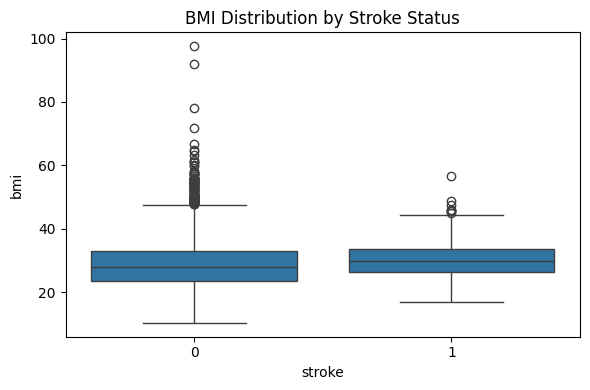

In [43]:
plt.figure(figsize=(6, 4))

sns.boxplot(x="stroke", y="bmi", data=df)
plt.title("BMI Distribution by Stroke Status")
plt.tight_layout()
plt.savefig("../outputs/figures/bmi_distribution_of_stroke_status.png", dpi=150, bbox_inches='tight')
plt.show()

The analysis shows that patients who experienced a stroke have a slightly higher average BMI compared to those who did not. However, the difference is modest, suggesting that BMI alone is not a strong discriminator between the two groups.

This is further supported by the boxplot, which shows substantial overlap in BMI distributions across both classes, indicating limited separation power. While BMI may contribute some predictive value, it is likely more useful when combined with other risk factors such as age and average glucose level.

Additionally, the non-stroke group exhibits a wider range of extreme BMI values, including several outliers, suggesting greater variability in BMI among individuals without stroke.

In [47]:
pd.read_sql_query("""
   SELECT hypertension,
       COUNT(*) AS total_counts,
       SUM(stroke) AS stroke_patients,
       ROUND(SUM(stroke) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    GROUP BY hypertension;
   """, conn) 

,hypertension,total_counts,stroke_patients,stroke_percentage
0,0,4612,183,3.97
1,1,498,66,13.25


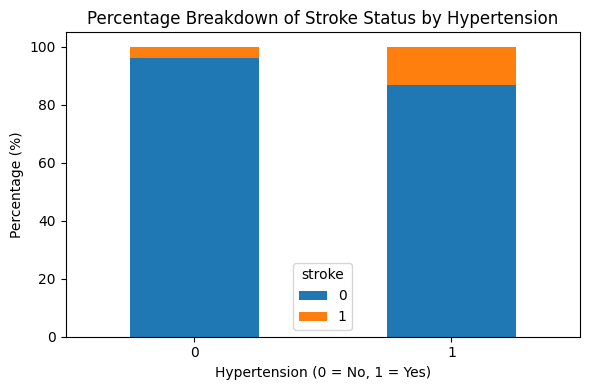

In [52]:
hypertension_stroke_pct = pd.crosstab(df["hypertension"], df["stroke"], normalize="index") * 100

hypertension_stroke_pct.plot(
    kind="bar", stacked=True, figsize=(6, 4)
)

plt.title("Percentage Breakdown of Stroke Status by Hypertension")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/hypertension_vs_stroke_stacked.png", bbox_inches="tight")
plt.show()

The data in this dataset reveals that individuals with hypertension have a substantially higher stroke rate of 13.25% (66 out of 498 patients) compared to just 3.97% (183 out of 4,612 patients) for those without it, confirming high blood pressure as a major risk factor while highlighting a clear baseline class imbalance.

In [53]:
pd.read_sql_query("""
   SELECT heart_disease,
       COUNT(*) AS total_counts,
       SUM(stroke) AS stroke_patients,
       ROUND(SUM(stroke) * 100.0 / COUNT(*), 2) AS stroke_percentage
    FROM stroke
    GROUP BY heart_disease;
   """, conn) 

,heart_disease,total_counts,stroke_patients,stroke_percentage
0,0,4834,202,4.18
1,1,276,47,17.03


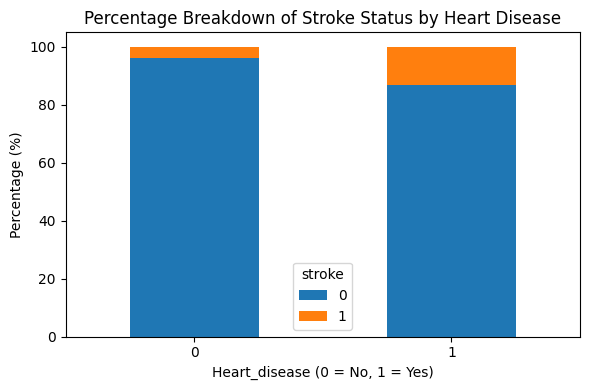

In [54]:
heart_disease_stroke_pct = pd.crosstab(df["heart_disease"], df["stroke"], normalize="index") * 100

hypertension_stroke_pct.plot(kind="bar", stacked=True, figsize=(6, 4))

plt.title("Percentage Breakdown of Stroke Status by Heart Disease")
plt.xlabel("Heart_disease (0 = No, 1 = Yes)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/heart_disease_vs_stroke_stacked.png", bbox_inches="tight")
plt.show()

The Data in this dataset demonstrates a strong association between cardiovascular health and stroke risk, showing that individuals with heart disease experience a dramatically higher stroke rate of 17.03% (47 out of 276 patients) compared to just 4.18% (202 out of 4,834 patients) for those without it.

This step helps us understand the dataset size (rows and columns) and inspect the data types of each feature to ensure everything is correctly formatted before further analysis.

In [ ]:
print(df.shape)
df.info()

(5110, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


The dataset contains 5,110 patient records and 12 columns. The BMI column has 
201 missing values (4909 non-null out of 5110). All other columns are complete. 
The id column will be dropped before modeling as it carries no predictive value. 
Data types appear correct with numeric columns either stored as float64 or int64, and categorical 
columns are stored as strings.

In [55]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


The statistical summary is essential because it provides an immediate baseline audit of data integrity, highlighting missing values, extreme outliers, feature distributions, and severe class imbalances that dictate how data is cleaned and modeling strategies.

In [11]:
# checking for missing values

missing_values = df.isnull().sum()
print(missing_values[missing_values>0])

bmi    201
dtype: int64


Only the BMI column has missing values (201 records, approximately 4% of the dataset). 
This is a relatively small proportion and will be handled by imputation rather than 
dropping rows, since removing 201 rows would reduce an already small dataset further. 
The imputation strategy will be decided after examining the BMI distribution.

In [12]:
# checking the target distribution
df['stroke'].value_counts()
df['stroke'].value_counts(normalize=True).round(3)

stroke
0    0.951
1    0.049
Name: proportion, dtype: float64

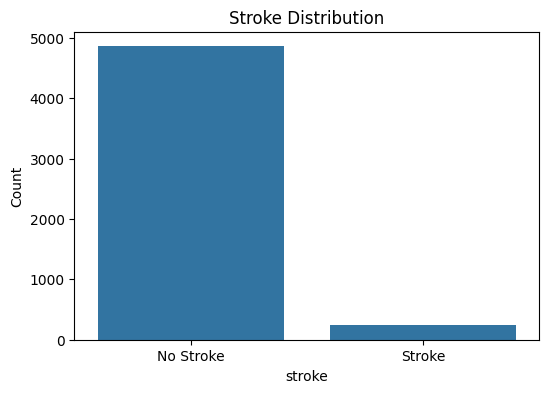

In [13]:
# plotting target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/stroke_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


The target variable is heavily imbalanced: about 95.1% of patients did not have a stroke, while only 4.9% did. This means a naive model that always predicts “no stroke” could still achieve around 95% accuracy, even though it would be clinically useless. Because of this imbalance, it’s important to handle it during modeling using techniques such as class weights, SMOTE, or threshold tuning so the model can better detect actual stroke cases.

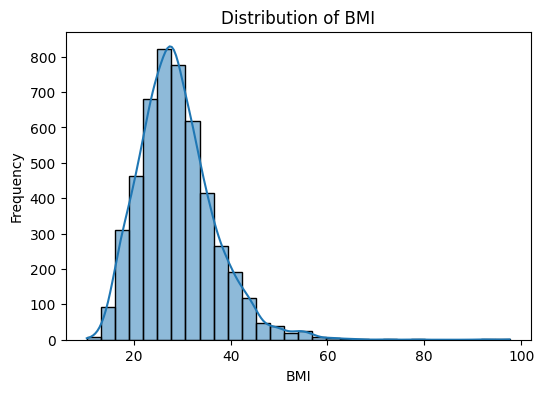

In [14]:
# Key feature distribution: BMI

plt.figure(figsize=(6, 4))
sns.histplot(df["bmi"], bins=30, kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.savefig('../outputs/figures/bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

BMI follows an approximately normal distribution with a slight right skew, centered 
around 25-30. A small number of extreme high values are visible above 60 which will 
be investigated as potential outliers. Since the distribution is roughly symmetric, 
median imputation will be used to fill the 201 missing values.

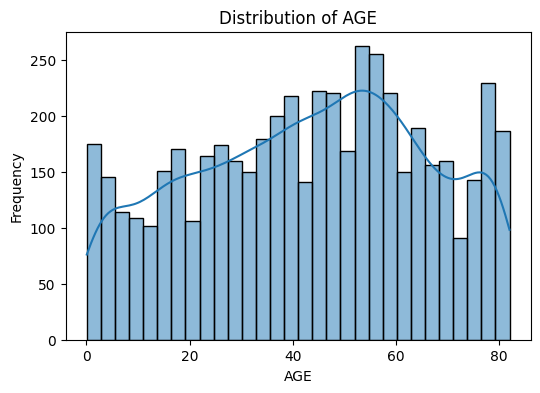

In [15]:
# Key feature distribution: AGE

plt.figure(figsize=(6, 4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of AGE")
plt.xlabel("AGE")
plt.ylabel("Frequency")
plt.savefig('../outputs/figures/age_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

The age distribution is fairly uniform across all age groups from 0 to 82, with a 
slight peak around 50-60 years. Stroke risk is expected to increase with age which will be 
captured through age group binning in feature engineering.

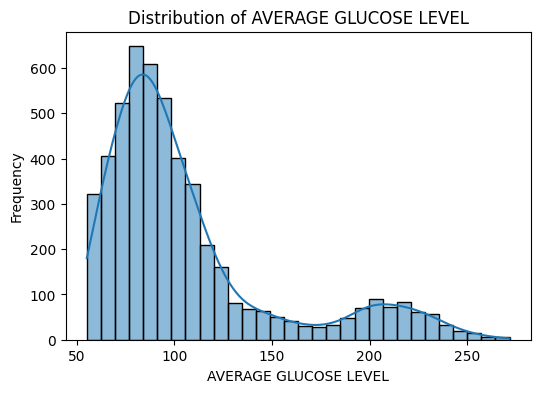

In [16]:
# Key feature distribution: AVERAGE GLUCOSE LEVEL

plt.figure(figsize=(6,4))
sns.histplot(df["avg_glucose_level"], bins=30, kde=True)
plt.title("Distribution of AVERAGE GLUCOSE LEVEL")
plt.xlabel("AVERAGE GLUCOSE LEVEL")
plt.ylabel("Frequency")
plt.savefig('../outputs/figures/avg_glu_level_distribution.png', dpi=150, bbox_inches='tight')

plt.show()



The glucose distribution exhibits a bimodal pattern, with one peak representing normal glucose levels and another representing elevated glucose levels. This supports earlier findings that stroke patients tend to have higher glucose levels and suggests that elevated glucose may be an important risk factor associated with stroke occurrence.

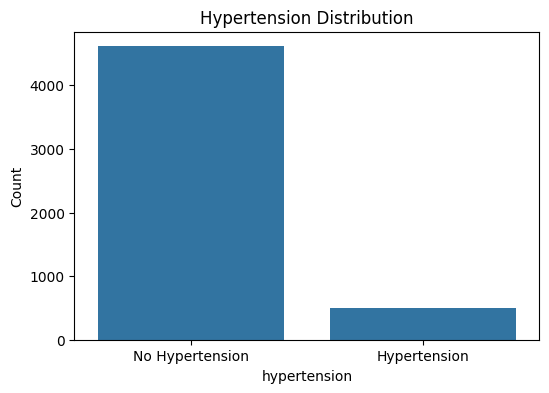

In [17]:
# Key feature distribution: HYPERTENSION
plt.figure(figsize=(6,4))
sns.countplot(x='hypertension', data=df)
plt.title("Hypertension Distribution")
plt.xticks([0, 1], ['No Hypertension', 'Hypertension'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/hypertension_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The majority of patients, approximately 90% do not have hypertension. Only a small 
proportion have hypertension. Despite this imbalance within the feature itself, 
hypertension is a known clinical risk factor for stroke and will be retained as a 
feature. It will also be combined with heart disease to create a cardiovascular risk 
score in feature engineering.

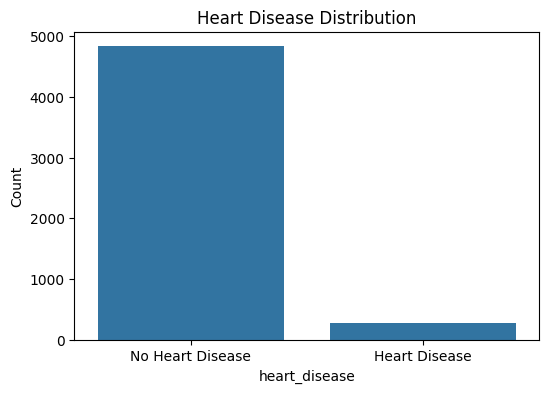

In [18]:
# Key feature distribution: HEART DISEASE
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
plt.ylabel('Count')
plt.savefig('../outputs/figures/heart_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Similar to hypertension, heart disease is present in a small minority of patients. 
The overwhelming majority have no recorded heart disease. Like hypertension, this 
binary feature carries important clinical significance for stroke prediction and will 
be retained. The combination of both hypertension and heart disease into a single 
cardiovascular risk feature will help capture compounded risk in patients with both 
conditions.

### Data Cleaning



Prior to modeling, raw datasets must undergo Exploratory Data Analysis and cleaned to handle structural inconsistencies, and ensure high data integrity. Initial inspection of the dataset via `df.describe()` has already revealed that the `bmi` feature contains **201 missing values** (4,909 non-null records out of 5,110 entries). 

The following pipeline will systematically address these missing entries, isolate extreme outliers, and standardize data types to prepare the dataset for machine learning.

In [62]:
# filling missing values in BMI column
instructions = {
    'bmi':'median'
}
df = handle_missing(df, instructions, fill_value=None)



We selected **median imputation** over mean imputation to handle the 201 missing values in the `bmi` feature. As established during EDA, the `bmi` distribution is heavily right-skewed with extreme upper outliers (stretching to a maximum value of 97.6, while the 75th percentile sits at 33.1). Using the mean in a skewed distribution will pull the imputed values upward, artificially distorting the feature's variance. 

In [65]:
# checking if there is still any missing value

missing_values = df.isnull().sum()
missing_values[missing_values>0]
print("There are no more missing values. ")

There are no more missing values. 


In [66]:
# checking for and removing duplicates rows
df = remove_duplicates(df)

Removed 0 duplicate rows — 5110 rows remaining


There was no duplicate rows in our dataset.

In [68]:
# dropping the ID column

df = df.drop("id", axis=1)

The ID column was dropped because it does not help prediction and might just introduce noise.
The `id` column was removed because it serves only as a unique identifier for each patient and does not contain information relevant to stroke prediction, Including such identifiers can introduce noise into the model without contributing meaningful predictive value.

In [69]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [72]:
df = df[df["gender"] != "Other"]
df = df.reset_index(drop=True)

In [73]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

During the initial data exploration, the `gender` feature revealed three unique categories: `Female`, `Male`, and `Other`. Further analysis showed that the `Other` category consists of **only a single record** out of 5,110 entries. 

The decision was made for it to be dropped, Because a single observation provides zero statistical significance and insufficient variance for machine learning algorithms to learn from. 

In [76]:
df["bmi"].describe()

count    5109.000000
mean       28.863300
std         7.699785
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

In [75]:
df["bmi"].quantile([0.95, 0.99, 0.995, 0.999])

0.950    42.6600
0.990    52.8920
0.995    55.9000
0.999    64.7568
Name: bmi, dtype: float64

The statistical summary of BMI shows that there are outliers with the 75th percentile being `32.8` and the max being `97.6`. The gap is huge and suggests the presence of outliers. Further analysis was done.
The `bmi` contains a small number of extreme observations. The 99th percentile BMI is 52.89, while a few records exceed 70. Although these values are statistically outlying, they remain within the range of medically plausible BMI measurements and were therefore retained. Their impact on model performance will be assessed during feature engineering and model evaluation.

In [78]:
# cleaning strings

df = clean_strings(df)

Cleaned 5 string column(s)


String cleaning standardizes text data by removing trailing whitespaces, normalizing letter cases, and fixing typos, preventing computers from treating identical categories as entirely separate values.

In [81]:
# saving the cleaned dataset
df.to_csv("../data/processed/stroke_cleaned.csv", index=False)

### Feature Engineering and Encoding